In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path


In [10]:
image_path = Path('/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.pgm')
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")

Processing /home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.pgm...


In [11]:
map_folder = image_path.parent

In [12]:
# log content
map_config_file = map_folder / 'map.yaml'
with open(map_config_file, 'r') as f:
    log_content = f.readlines()
log_content = [line.strip() for line in log_content if line.strip()]
log_content

['image: map.pgm',
 'mode: trinary',
 'resolution: 0.05',
 'origin: [-5.34, -7.49, 0]',
 'negate: 0',
 'occupied_thresh: 0.65',
 'free_thresh: 0.25']

In [13]:
# List the directory contents recursively
def list_files_recursively(directory):
    for path in directory.rglob('*'):
        if path.is_file():
            print(path)
list_files_recursively(map_folder)

/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.pgm
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.data
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.yaml
/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/map.posegraph


[ WARN:0@327.631] global loadsave.cpp:268 findDecoder imread_('/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025-improved-odom-refined/racing_lines/1/map_race_line_drawn_with_slow_areas.png'): can't open/read file: check file path/integrity


TypeError: Image data of dtype object cannot be converted to float

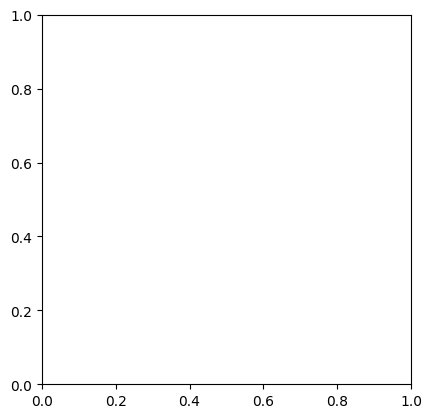

In [14]:
# Load racing_lines/map_race_line_drawn.png
racing_lines_path = map_folder / 'racing_lines' / '1' /'map_race_line_drawn_with_slow_areas.png'
# racing_lines = cv2.imread(str(racing_lines_path), cv2.COLOR_RGB2BGR)
racing_lines = cv2.imread(str(racing_lines_path), cv2.COLOR_BGR2RGB)
# racing_lines = cv2.imread(str(racing_lines_path), cv2.COLOR_BGR2GRAY)
# Show the image
plt.imshow(racing_lines)

In [ ]:
def mask_red_regions(image):
    # Convert the image from BGR to HSV color space
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define the range for red color in HSV
    # Red has two ranges in HSV due to the hue wrapping around 0/360 degrees
    # We lower the minimum Saturation (S) and Value (V) to capture more shades (pinks, maroons, dark reds)
    lower_red1 = np.array([0, 50, 50])    # Lower bound for red (0-10 hue), minimum S and V set to 50
    upper_red1 = np.array([10, 255, 255])   # Upper bound for red (full S and V)

    lower_red2 = np.array([170, 50, 50])  # Lower bound for red (170-180 hue), minimum S and V set to 50
    upper_red2 = np.array([180, 255, 255])  # Upper bound for red (full S and V)
    
    # Create masks for both red ranges
    mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
    
    # Combine the masks (bitwise OR)
    red_mask = cv2.bitwise_or(mask1, mask2)
    
    # Apply the mask to the original image
    red_only_image = cv2.bitwise_and(image, image, mask=red_mask)
    
    return red_only_image

In [ ]:
racing_line = mask_red_regions(racing_lines)


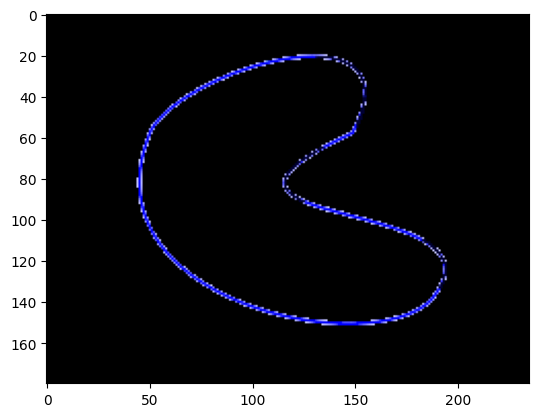

In [ ]:
# Show the image
plt.imshow(racing_line)

In [ ]:
import cv2
import numpy as np
from typing import List

def get_points_from_image(image: np.ndarray) -> np.ndarray:
    """
    Processes an image to find and extract points from the first contour.

    Args:
        image: The input image as a NumPy array (expected to be grayscale or color).

    Returns:
        An (N, 2) NumPy array of (x, y) coordinates as float64,
        representing the points of the first found contour.
        Returns an empty array if no contours are found.
    """
    # Input 'image' is hinted as np.ndarray

    if len(image.shape) == 3:  # Check if image is color (3 channels)
        # Type hint 'image' inside the if block could specify shape, but often not needed
        # image: np.ndarray[(Any, Any, Any), Any] # More specific but verbose
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # After this line, 'image' is a grayscale np.ndarray[(Any, Any), Any]

    # Ensure the skeleton is binary (0 or 255)
    # cv2.threshold returns a tuple (threshold_value, thresholded_image)
    # The type of the second element is np.ndarray[(Any, Any), np.dtype[np.uint8]]
    _, binary_image = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)

    # Find contours
    # cv2.findContours returns a tuple (contours, hierarchy) or (image, contours, hierarchy) depending on OpenCV version
    # 'contours' is a list of numpy arrays. Each array is np.ndarray[(Any, 1, 2), np.dtype[np.int32]]
    contours: List[np.ndarray] # Hint the type of the 'contours' variable
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    print(f"Found {len(contours)} contours")

    # Check if any contours were found
    if not contours:
        print("Error: No contours found. Ensure the skeleton contains non-zero pixels.")
        # Return type is explicitly np.ndarray, so return an empty one with correct dtype
        return np.array([], dtype=np.float64).reshape(0, 2) # Ensure it's (0, 2) shape

    # Select the first contour (assuming a single skeleton line)
    # 'contour' is np.ndarray[(Any, 1, 2), np.dtype[np.int32]]
    contour = contours[0]

    # Extract points from the contour and reshape
    # Reshaped 'points_reshaped' is np.ndarray[(Any, 2), np.dtype[np.int32]]
    points_reshaped = contour.reshape(-1, 2)

    # Convert to float64 as required by the function's return type
    # 'points' is np.ndarray[(Any, 2), np.dtype[np.float64]]
    points: np.ndarray = points_reshaped.astype(np.float64) # Hint the type of the final 'points' variable

    print(f"Extracted {len(points)} points from contour")
    return points # Return value is hinted as np.ndarray

In [ ]:
racing_line_points = get_points_from_image(racing_line)
# racing_line_points.reshape(2, -1)
racing_line_points.shape

Found 1 contours
Extracted 460 points from contour


(460, 2)

In [ ]:
def sample_waypoints(points: np.ndarray, num_points: int) -> np.ndarray:
    """
    Sample a specified number of waypoints evenly along a polyline defined by points.

    Args:
        points: An (N,2) array of (x,y) coordinates defining the path.
        num_points: Number of waypoints to sample.

    Returns:
        An (num_points,2) array of sampled (x,y) coordinates.
    """
    # Compute segment lengths
    diffs = np.diff(points, axis=0)
    seg_lengths = np.hypot(diffs[:,0], diffs[:,1])
    cumulative = np.concatenate(([0], np.cumsum(seg_lengths)))
    total_length = cumulative[-1]

    # Desired distances along the path
    distances = np.linspace(0, total_length, num_points)

    # Allocate output
    waypoints = np.zeros((num_points, 2), dtype=float)

    # Walk through segments to interpolate
    idx = 0
    for i, d in enumerate(distances):
        # Move idx to segment containing this distance
        while idx < len(cumulative)-2 and d > cumulative[idx+1]:
            idx += 1
        # Interpolate between points[idx] and points[idx+1]
        t = (d - cumulative[idx]) / (cumulative[idx+1] - cumulative[idx]) if cumulative[idx+1] > cumulative[idx] else 0
        waypoints[i] = (1 - t) * points[idx] + t * points[idx+1]
    return waypoints

In [ ]:
sampled_points = sample_waypoints(racing_line_points, 100)
sampled_points.shape

(100, 2)

Text(0.5, 1.0, 'Sampled Points on Racing Line')

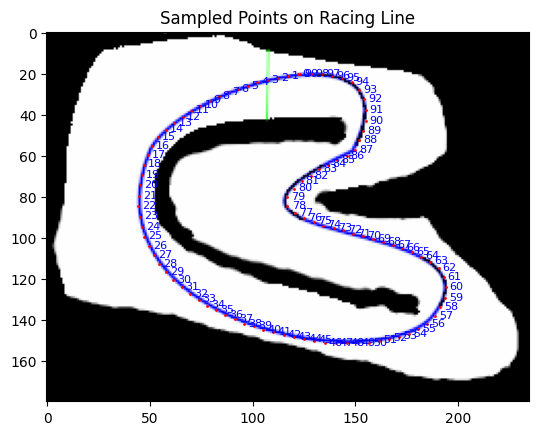

In [ ]:
# show the sampled points
plt.imshow(racing_lines)
plt.scatter(sampled_points[:, 0], sampled_points[:, 1], c='red', s=1)
# Add the index text next to each point
for i, point in enumerate(sampled_points):
    # point is like [x, y]
    x, y = point[0], point[1]
    # Add text slightly offset from the point for better visibility
    plt.text(x + 2, y + 2, str(i), color='blue', fontsize=8, ha='left', va='bottom')

plt.title('Sampled Points on Racing Line')


In [ ]:
import cv2
import yaml

def load_yaml(yaml_file: str) -> dict:
    """Load and parse the ROS .yaml file."""
    with open(yaml_file, 'r') as file:
        map_data = yaml.safe_load(file)
    return map_data

def map_image_to_world(points, yaml_file, image_height):
    """
    Map image pixel coordinates to world coordinates using ROS .yaml metadata.
    
    Args:
        points: List of [x, y] pixel coordinates from the image.
        yaml_file: Path to the ROS .yaml file.
        image_height: Height of the original map image in pixels.
    
    Returns:
        List of [x_world, y_world] coordinates in the world frame.
    """
    # Load .yaml file
    map_data = load_yaml(yaml_file)
    resolution = map_data['resolution']  # Meters per pixel
    origin_x = map_data['origin'][0]    # World x-coordinate of bottom-left pixel
    origin_y = map_data['origin'][1]    # World y-coordinate of bottom-left pixel
    
    # Convert pixel coordinates to world coordinates
    world_points = []
    for x_pixel, y_pixel in points:
        # Map x_pixel to world x
        x_world = origin_x + (x_pixel * resolution)
        
        # Map y_pixel to world y (invert y-axis)
        y_world = origin_y + ((image_height - y_pixel) * resolution)
        
        world_points.append([x_world, y_world])
    
    return world_points

In [ ]:
len(racing_line_points)

460

In [ ]:

# Load the original map image to get its dimensions
map_file_path = map_folder /'map.pgm'
map_file_path

PosixPath('/home/aj/workspaces/boticar-f1tenth-car-ros2/src/boticar_bringup/maps/bauhaus_26-4-2025_sim_4-5-2025_edited/map.pgm')

In [ ]:

original_map_image = cv2.imread(map_file_path, cv2.IMREAD_GRAYSCALE)  # Path from .yaml
original_map_image

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(180, 235), dtype=uint8)

In [ ]:


if original_map_image is None:
    raise ValueError("Could not load the original map image")
image_height = original_map_image.shape[0]  # Height in pixels

# Map the points to world coordinates
world_coordinates = np.array(map_image_to_world(sampled_points, map_config_file, image_height))

In [ ]:
len(world_coordinates[:, 0]), len(world_coordinates[:, 1])

(100, 100)

In [ ]:
csv_file_path_racing_line = output_path / 'racing_line_coordinates.csv'
csv_file_path_racing_line

PosixPath('../output/racing_line_coordinates.csv')

In [ ]:
# Create a csv file to save the world coordinates
import pandas as pd

# Add the racing line points to the csv file
df_racing_line = pd.DataFrame()
df_racing_line['x_world'] = world_coordinates[:, 0]
df_racing_line['y_world'] = world_coordinates[:, 1]

df_racing_line.to_csv(csv_file_path_racing_line, index=False)


# Print or use the world coordinates
for x_world, y_world in world_coordinates:
    print(f"World coordinate: ({x_world:.3f}, {y_world:.3f})")


World coordinate: (0.590, 0.390)
World coordinate: (0.341, 0.340)
World coordinate: (0.092, 0.290)
World coordinate: (-0.156, 0.240)
World coordinate: (-0.405, 0.190)
World coordinate: (-0.633, 0.090)
World coordinate: (-0.875, 0.025)
World coordinate: (-1.110, -0.060)
World coordinate: (-1.338, -0.160)
World coordinate: (-1.564, -0.264)
World coordinate: (-1.784, -0.384)
World coordinate: (-2.001, -0.510)
World coordinate: (-2.209, -0.659)
World coordinate: (-2.416, -0.810)
World coordinate: (-2.620, -0.970)
World coordinate: (-2.810, -1.160)
World coordinate: (-2.965, -1.365)
World coordinate: (-3.060, -1.595)
World coordinate: (-3.160, -1.824)
World coordinate: (-3.210, -2.072)
World coordinate: (-3.260, -2.321)
World coordinate: (-3.282, -2.582)
World coordinate: (-3.289, -2.831)
World coordinate: (-3.260, -3.088)
World coordinate: (-3.210, -3.337)
World coordinate: (-3.142, -3.578)
World coordinate: (-3.022, -3.798)
World coordinate: (-2.910, -4.021)
World coordinate: (-2.782, -4.